# SHOTpy Tutorial - Advanced Usage and Extensions

This notebook demonstrates how SHOT can be used in a Python ecosystem. The problem and modelling are based on **[1, 2]** and parts of the code have been generated with AI.


**[1]** Harjunkoski, I., Pörn, R., & Westerlund, T. (2025). MINLP: Trim-Loss Problem. In P. M. Pardalos, & O. A. Prokopyev (Eds.), Encyclopedia of Optimization (pp. 1-10). Springer, Cham. https://doi.org/10.1007/978-3-030-54621-2_387-1


**[2]** I. Harjunkoski, R. Pörn, T. Westerlund, H. Skrifvars. Different strategies for solving bilinear integer non-linear programming problems with convex transformations,
Computers & Chemical Engineering, Volume 21, Supplement, 1997, Pages S487-S492. https://doi.org/10.1016/S0098-1354(97)87549-7.

## SHOT in Python Ecosystem: Trim-Loss Problem

In paper production, large jumbo rolls are cut into smaller rolls of specified widths using predefined cutting patterns. Because customer orders differ in both width and quantity, not all material can be fully utilized. The remaining unusable material, known as trim loss, is typically recycled or reprocessed, which incurs additional operational costs and increases energy, water, and chemical consumption. Therefore, minimizing trim loss is a key objective in reducing both production cost and environmental impact.

**Sets**
- $I$: Set of product (roll width) types, indexed by $i$
- $J$: Set of cutting patterns, indexed by $j$

**Parameters**
- $w_i$: Width of product $i \in I$
- $W_{j,\max}$: Width of raw paper (jumbo reel) used in cutting pattern $j \in J$
- $T_j$: Maximum allowable trim-loss width for pattern $j \in J$
- $N_{j,\max}$: Maximum number of products that can be cut in pattern $j \in J$
- $M_j$: Upper bound on the number of times pattern $j \in J$ is repeated
- $n_{i,\text{order}}$: Ordered quantity (demand) of product $i \in I$
- $c_j$: Cost coefficient for the number of repetitions of pattern $j \in J$
- $C_j$: Cost coefficient for the activation of pattern $j \in J$

**Variables**
- $n_{ij} \in \mathbb{Z}_{\ge 0}$: Number of times product $i \in I$ appears in cutting pattern $j \in J$
- $m_j \in \mathbb{Z}_{\ge 0}$: Number of times cutting pattern $j \in J$ is repeated
- $y_j \in \{0,1\}$: Binary variable equal to $1$ if cutting pattern $j \in J$ is used, $0$ otherwise

**Model**
\begin{align}
\min_{m_j, n_{ij}, y_j} \quad & \sum_{j=1}^{J} \left( c_j \cdot m_j + C_j \cdot y_j \right) 
    && \text{(minimize total patterns and pattern changes)} \\[6pt]
\text{s.t.} \quad
& \sum_{i=1}^{I} w_i \cdot n_{ij} \leq W_{j,\max} 
    && \text{(cuts must not exceed raw paper width)} \\
&  W_{j,\max} - T_j \leq \sum_{i=1}^{I} w_i \cdot n_{ij}
    && \text{(trim loss must not exceed maximum allowable width)} \\
& \sum_{i=1}^{I} n_{ij} \leq N_{j,\max} 
    && \text{(number of cuts per pattern bounded by } N_{j,\max}\text{)} \\
& y_j \leq  m_j
    && \text{(pattern } j \text{ must be active if used)} \\
& m_j \leq  M_j \cdot y_j, \qquad j = 1, \ldots, J 
    && \text{(pattern repetitions bounded by } M_j \text{ if active)} \\
& n_{i,\text{order}}\leq \sum_{j=1}^{J} m_j \cdot n_{ij}, \qquad i = 1, \ldots, I 
    && \text{(bilinear demand constraint: customer order must be met)} \\
& m_j,\, n_{ij} \in \mathbb{Z}, \quad y_j \in \{0, 1\} 
    && \text{(integrality and binary requirements)}
\end{align}


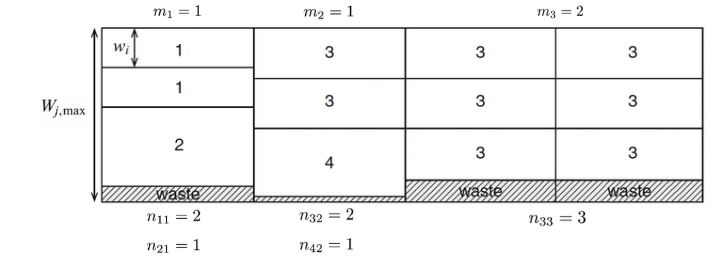

**Figure 1:** Trimm-Loss Problem **[1]**. 


For simplicity, assume we want to solve an instance where:

- $I = \{1, 2\}$
- $J = \{1, 2\}$
- $w_i = \{3, 5\}$ (cm)
- $W_{j,\max} = \{20, 20\}$
- $T_j = \{2, 2\}$
- $N_{j,\max} = \{4, 4\}$
- $M_j = \{10, 10\}$
- $n_{i,\text{order}} = \{10, 6\}$
- $c_j = \{2, 1\}$
- $C_j = \{5, 3\}$


Also note that the Trim-Loss problem is a nonconvex MINLP problem. However, it can, *e.g.*, be written as a convex MINLP formulation (see **[2]**). As the focus of this tutorial is to demonstrate how SHOT can be used in a Python ecosystem, 

#### Step 1: Loading Problem Data
Let's start with loading the problem data from the CSV-files.

In [17]:
import pandas as pd
from IPython.display import display, HTML

products = pd.read_csv("products.csv")
products.columns = [c.strip().replace('_', ' ').title() for c in products.columns]

display(HTML(products.to_html(index=False, float_format="%.2f")))

# product, w_i, order
df = pd.read_csv("products.csv")
products = df['product'].tolist()
weights = df['w_i'].tolist()
orders = df['order'].tolist()

print("Products:", products)
print("Weights:", weights)
print("Orders:", orders)

patterns = pd.read_csv("patterns.csv")
patterns.columns = [c.strip().replace('_', ' ').title() for c in patterns.columns]

display(HTML(patterns.to_html(index=False, float_format="%.2f")))

# pattern,W_max,T_j,N_max,M_j,c_j,C_j
df = pd.read_csv("patterns.csv")
patterns = df['pattern'].tolist()
weights_max = df['W_max'].tolist()
Trimm = df['T_j'].tolist()
N_max = df['N_max'].tolist()
M_j = df['M_j'].tolist()
cost_rep = df['c_j'].tolist()
cost_act = df['C_j'].tolist()

print("Patterns:", patterns)
print("Weights_max:", weights_max)
print("Trimm:", Trimm)
print("Max N products:", N_max)
print("Max M patterns:", M_j)
print("Cost_rep:", cost_rep)
print("Cost_act:", cost_act)

Product,W I,Order
Pr1,3,10
Pr2,5,6
Pr3,4,12
Pr4,6,8
Pr5,4,12


Products: ['Pr1', 'Pr2', 'Pr3', 'Pr4', 'Pr5']
Weights: [3, 5, 4, 6, 4]
Orders: [10, 6, 12, 8, 12]


Pattern,W Max,T J,N Max,M J,C J,C J
Pa1,20,2,4,10,2,5
Pa2,20,2,4,10,1,3
Pa3,20,3,3,12,3,4
Pa4,20,4,3,11,1,4
Pa5,20,3,3,8,4,4
Pa6,20,4,3,9,5,4


Patterns: ['Pa1', 'Pa2', 'Pa3', 'Pa4', 'Pa5', 'Pa6']
Weights_max: [20, 20, 20, 20, 20, 20]
Trimm: [2, 2, 3, 4, 3, 4]
Max N products: [4, 4, 3, 3, 3, 3]
Max M patterns: [10, 10, 12, 11, 8, 9]
Cost_rep: [2, 1, 3, 1, 4, 5]
Cost_act: [5, 3, 4, 4, 4, 4]


Looks good!

### Step 2: Build and Solve the Trim-Loss Model

First, import the SHOTpy module and create an environment.

In [18]:
import sys
import os
from pathlib import Path

# Find SHOTpy module
base = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
repo_root = base.parent   # one level up; use .parent.parent for two levels, etc.
sys.path.insert(0, str(repo_root))

import SHOTpy

# Create a SHOT solver and get its environment
solver = SHOTpy.Solver()
env = solver.getEnvironment()
print("SHOT solver and environment created successfully!")

SHOT solver and environment created successfully!


Now, let's create the model.

In [47]:
# Create solver and get environment
solver = SHOTpy.Solver()
env = solver.getEnvironment()

# Create a new problem
problem = SHOTpy.Problem(env)

# Sets
n_products = len(products)
I = list(range(n_products)) # set of products

n_patterns = len(patterns)
J = list(range(n_patterns)) # set of patterns

# Variables
idx = 0
n = {}  
m = {}
y = {}

for i in I: 
    for j in J:
        n[i,j] = SHOTpy.Variable(f"n_{i+1}_{j+1}", idx, SHOTpy.VariableType.Integer, 0, SHOTpy.SHOT_DBL_MAX)
        problem.addVariable(n[i,j]) 
        idx += 1

for j in J:
    UB_m = M_j[j]  # upper bound for m_j
    m[j] = SHOTpy.Variable(f"m_{j+1}", idx, SHOTpy.VariableType.Integer, 0, UB_m)
    problem.addVariable(m[j])
    idx += 1

    y[j] = SHOTpy.Variable(f"y_{j+1}", idx, SHOTpy.VariableType.Binary, 0, 1)
    problem.addVariable(y[j])
    idx += 1

# Objective
objective = SHOTpy.LinearObjectiveFunction(SHOTpy.ObjectiveDirection.Minimize)

for j in J: # for each pattern, add the cost of using the pattern
    c_j = cost_rep[j]  # cost of using pattern j
    objective.add(SHOTpy.LinearTerm(c_j, m[j]) )

    C_j = cost_act[j]  # cost of using pattern j
    objective.add(SHOTpy.LinearTerm(C_j, y[j]) )

problem.setObjective(objective)

# Constraints 
con_idx = 0

# (2)+(3) Width bounds per pattern (double-sided):
#   weights_max[j] - Trimm[j]  <=  Σ_i weights[i] · n_ij  <=  weights_max[j]
for j in J:
    lb = float(weights_max[j] - Trimm[j])
    ub = float(weights_max[j])
    cons = SHOTpy.LinearConstraint(con_idx, f"width_{j+1}", lb, ub)
    for i in I:
        cons.add(SHOTpy.LinearTerm(float(weights[i]), n[i, j]))
    problem.addConstraint(cons)
    con_idx += 1

# (4) Max cuts per pattern:  Σ_i n_ij  <=  N_max[j]
for j in J:
    cons = SHOTpy.LinearConstraint(con_idx, f"max_cuts_{j+1}", -SHOTpy.SHOT_DBL_MAX, float(N_max[j]))
    for i in I:
        cons.add(SHOTpy.LinearTerm(1.0, n[i, j]))
    problem.addConstraint(cons)
    con_idx += 1

# (5) Pattern must be active if used:  y_j - m_j  <=  0
for j in J:
    cons = SHOTpy.LinearConstraint(con_idx, f"active_if_used_{j+1}", -SHOTpy.SHOT_DBL_MAX, 0.0)
    cons.add(SHOTpy.LinearTerm( 1.0, y[j]))
    cons.add(SHOTpy.LinearTerm(-1.0, m[j]))
    problem.addConstraint(cons)
    con_idx += 1

# (6) Repetitions bounded when active:  m_j - M_j[j] · y_j  <=  0
for j in J:
    cons = SHOTpy.LinearConstraint(con_idx, f"bounded_if_active_{j+1}", -SHOTpy.SHOT_DBL_MAX, 0.0)
    cons.add(SHOTpy.LinearTerm( 1.0,          m[j]))
    cons.add(SHOTpy.LinearTerm(-float(M_j[j]), y[j]))
    problem.addConstraint(cons)
    con_idx += 1

# (7) Demand (bilinear):  Σ_j m_j · n_ij  >=  orders[i]
# for i in I:
#     cons = SHOTpy.QuadraticConstraint(con_idx, f"demand_{i+1}", float(orders[i]), SHOTpy.SHOT_DBL_MAX)
#     for j in J:
#         cons.add(SHOTpy.QuadraticTerm(1.0, m[j], n[i, j]))
#     problem.addConstraint(cons)
#     con_idx += 1

# The bilinear demand is nonconvex, so we reformulate. (technical details, not focus of tutorial)
import math

# New Variables 
# bm[j,l] ∈ {0,1}: encodes m_j = l when bm[j,l]=1,  l = 1,...,M_j[j]
# bn[i,j,k] ∈ {0,1}: encodes r_ij = k when bn[i,j,k]=1, where r_ij = N_max[j]-n_ij
#   k = 1,...,N_max[j]
#
# At most one bit per group fires (enforced by SOS-1 constraints below).
# If all bits = 0 → m_j = 0  or  r_ij = 0 (i.e., n_ij = N_max[j])

bm = {}
bn = {}

for j in J:
    for l in range(1, int(M_j[j]) + 1):
        bm[j, l] = SHOTpy.Variable(f"bm_{j+1}_{l}", idx, SHOTpy.VariableType.Binary, 0, 1)
        problem.addVariable(bm[j, l])
        idx += 1

for i in I:
    for j in J:
        for k in range(1, int(N_max[j]) + 1):
            bn[i, j, k] = SHOTpy.Variable(f"bn_{i+1}_{j+1}_{k}", idx,
                                            SHOTpy.VariableType.Binary, 0, 1)
            problem.addVariable(bn[i, j, k])
            idx += 1

# (7a) Definition of m_j via binary expansion (eq. 38):
#   m_j = Σ_{l=1}^{M_j[j]} l · bm[j,l]   →   m_j - Σ_l l·bm[j,l] = 0
for j in J:
    cons = SHOTpy.LinearConstraint(con_idx, f"mj_def_{j+1}", 0.0, 0.0)
    cons.add(SHOTpy.LinearTerm(1.0, m[j]))
    for l in range(1, int(M_j[j]) + 1):
        cons.add(SHOTpy.LinearTerm(-float(l), bm[j, l]))
    problem.addConstraint(cons)
    con_idx += 1

# (7b) Definition of n_ij via r_ij = N_max[j] - n_ij (eq. 39):
#   n_ij + Σ_{k=1}^{N_max[j]} k · bn[i,j,k] = N_max[j]
for i in I:
    for j in J:
        cons = SHOTpy.LinearConstraint(con_idx, f"nij_def_{i+1}_{j+1}",
                                        float(N_max[j]), float(N_max[j]))
        cons.add(SHOTpy.LinearTerm(1.0, n[i, j]))
        for k in range(1, int(N_max[j]) + 1):
            cons.add(SHOTpy.LinearTerm(float(k), bn[i, j, k]))
        problem.addConstraint(cons)
        con_idx += 1

# (7c) linear surrogate for m_j: Σ_l bm[j,l] ≤ 1  (eq. 40)
for j in J:
    cons = SHOTpy.LinearConstraint(con_idx, f"sos1_bm_{j+1}", -SHOTpy.SHOT_DBL_MAX, 1.0)
    for l in range(1, int(M_j[j]) + 1):
        cons.add(SHOTpy.LinearTerm(1.0, bm[j, l]))
    problem.addConstraint(cons)
    con_idx += 1

# (7d) linear surrogate for r_ij: Σ_k bn[i,j,k] ≤ 1  (eq. 40)
for i in I:
    for j in J:
        cons = SHOTpy.LinearConstraint(con_idx, f"sos1_bn_{i+1}_{j+1}",
                                        -SHOTpy.SHOT_DBL_MAX, 1.0)
        for k in range(1, int(N_max[j]) + 1):
            cons.add(SHOTpy.LinearTerm(1.0, bn[i, j, k]))
        problem.addConstraint(cons)
        con_idx += 1

# (7e) Convex MINLP demand constraint, τ=1:
#
#   n_{i,order} - J + Σ_j exp(Mj_log + Rij) - Σ_j[(N_max[j]+1)·Σ_l l·bm + Σ_k k·bn] ≤ 0
#
#   Mj_log = Σ_l ln(l+1)·bm[j,l]     log-space image of m_j   (τ=1 → ln τ = 0)
#   Rij    = Σ_k ln(k+1)·bn[i,j,k]   log-space image of r_ij
#
#   Rearranged for SHOT (move constants to ub):
#   Σ_j exp(Mj_log+Rij) - Σ_j[(N_max[j]+1)·Σ_l l·bm + Σ_k k·bn]  ≤  J - n_{i,order}

for i in I:
    ub = float(len(J)) - float(orders[i])
    cons = SHOTpy.NonlinearConstraint(con_idx, f"demand_{i+1}",
                                       -SHOTpy.SHOT_DBL_MAX, ub)

    for j in J:
        # Log-space images (τ=1):
        Mj_log = sum(math.log(l + 1) * bm[j, l] for l in range(1, int(M_j[j]) + 1))
        Rij    = sum(math.log(k + 1) * bn[i, j, k] for k in range(1, int(N_max[j]) + 1))

        # +exp(Mj_log + Rij)  convex nonlinear term
        cons.add(SHOTpy.exp(Mj_log + Rij))

        # -(N_max[j]+1) · Σ_l l · bm[j,l]
        for l in range(1, int(M_j[j]) + 1):
            cons.add(SHOTpy.LinearTerm(-float(N_max[j] + 1) * float(l), bm[j, l]))

        # -Σ_k k · bn[i,j,k]
        for k in range(1, int(N_max[j]) + 1):
            cons.add(SHOTpy.LinearTerm(-float(k), bn[i, j, k]))

    problem.addConstraint(cons)
    con_idx += 1



# MIP solver selection
solver.updateSetting("MIP.Solver", "Dual", int(SHOTpy.MIPSolver.Cbc)) # Gurobi, Cplex, Cbc or Highs

# Finalize and solve
problem.finalize()
solver.setProblem(problem)
solver.solveProblem()


 Performing bound tightening on reformulated problem.


True

  - Bounds for 60 variables tightened in 0.31 s and 2 passes.
  - Objective bounds are: [0, 178]

╶ Interior point search ──────────────────────────────────────────────────────────────────────────────────────────────╴

 Strategy selected:          cutting plane minimax

    Iteration     │  Time  │    Cuts     │     Objective value     │  Objective diff.   
     #: type      │  tot.  │   + | tot.  │    problem | line srch  │    abs. | rel.    
╶─────────────────┴────────┴─────────────┴─────────────────────────┴──────────────────╴
     1: LP           0.37                      -1e+12 | -1e+12          inf. | inf.    
     2: LP           0.37      8 | 8         -54.7697 | 3.20381      5.8e+01 | 1.1e+00 
     3: LP           0.38      8 | 16        -32.2176 | 3.21545      3.5e+01 | 1.1e+00 
     4: LP           0.38      8 | 24        -31.2757 | 2.6372       3.4e+01 | 1.1e+00 
     5: LP           0.39      8 | 32         -31.189 | 1.75673      3.3e+01 | 1.1e+00 
     6: LP           0.4

In [48]:
# Print problem structure:
print("Problem Structure:")
print(problem.toString())

# Get results
sol = solver.getPrimalSolution()
if sol is None:
    print("No solution found")
else:
    print(f"Optimal objective value: {sol.objValue:.4f}")
    print(f"Optimal solution:")
    for i, val in enumerate(sol.point):
        var = problem.getVariable(i)
        print(f"{var.name} = {val:.4f}")

Problem Structure:
minimize:
[L-convex    ] [L    ]	  +2*m_1 +5*y_1 +m_2 +3*y_2 +3*m_3 +4*y_3 +m_4 +4*y_4 +4*m_5 +4*y_5 +5*m_6 +4*y_6

subject to:
[    0,L-convex    ] [L    ]      width_1:18 <=   +3*n_1_1 +5*n_2_1 +4*n_3_1 +6*n_4_1 +4*n_5_1 <= 20
[    1,L-convex    ] [L    ]      width_2:18 <=   +3*n_1_2 +5*n_2_2 +4*n_3_2 +6*n_4_2 +4*n_5_2 <= 20
[    2,L-convex    ] [L    ]      width_3:17 <=   +3*n_1_3 +5*n_2_3 +4*n_3_3 +6*n_4_3 +4*n_5_3 <= 20
[    3,L-convex    ] [L    ]      width_4:16 <=   +3*n_1_4 +5*n_2_4 +4*n_3_4 +6*n_4_4 +4*n_5_4 <= 20
[    4,L-convex    ] [L    ]      width_5:17 <=   +3*n_1_5 +5*n_2_5 +4*n_3_5 +6*n_4_5 +4*n_5_5 <= 20
[    5,L-convex    ] [L    ]      width_6:16 <=   +3*n_1_6 +5*n_2_6 +4*n_3_6 +6*n_4_6 +4*n_5_6 <= 20
[    6,L-convex    ] [L    ]   max_cuts_1:  +n_1_1 +n_2_1 +n_3_1 +n_4_1 +n_5_1 <= 4
[    7,L-convex    ] [L    ]   max_cuts_2:  +n_1_2 +n_2_2 +n_3_2 +n_4_2 +n_5_2 <= 4
[    8,L-convex    ] [L    ]   max_cuts_3:  +n_1_3 +n_2_3 +n_3_3 +n_4_3 +n_5_3 

### Step 3: Visualize 
Alright, let's visualize the solution.

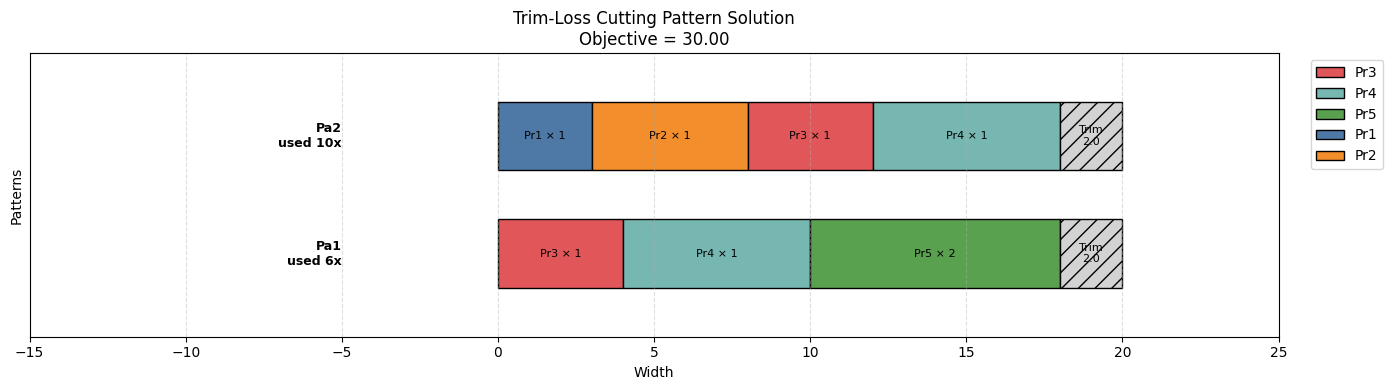

In [49]:
sol = solver.getPrimalSolution()

if sol is None:
    print("No solution found")

else:
    import pandas as pd
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
    import numpy as np

    # ------------------------------------------------------------
    # Extract solution values
    # ------------------------------------------------------------
    pattern_data = []

    for j in J:

        m_val = round(sol.point[m[j].index])

        # ignore unused patterns
        if m_val <= 0:
            continue

        cuts = []

        used_width = 0.0

        for i in I:

            n_val = round(sol.point[n[i, j].index])

            if n_val > 0:

                cuts.append({
                    "product": products[i],
                    "count": n_val,
                    "width": weights[i]
                })

                used_width += n_val * weights[i]

        trim = weights_max[j] - used_width

        pattern_data.append({
            "pattern": patterns[j],
            "repetitions": m_val,
            "roll_width": weights_max[j],
            "used_width": used_width,
            "trim": trim,
            "cuts": cuts
        })

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    fig_height = max(4, len(pattern_data) * 1.2)

    fig, ax = plt.subplots(figsize=(14, fig_height))

    color_palette = [
        "#4E79A7", "#F28E2B", "#E15759", "#76B7B2",
        "#59A14F", "#EDC948", "#B07AA1", "#FF9DA7",
        "#9C755F", "#BAB0AC"
    ]

    product_colors = {
        products[i]: color_palette[i % len(color_palette)]
        for i in I
    }

    y_pos = 0
    bar_height = 0.7

    legend_handles = {}

    for pdata in pattern_data:

        x_start = 0

        # draw cuts
        for cut in pdata["cuts"]:

            product = cut["product"]
            count = cut["count"]
            width = cut["width"]

            total_segment_width = count * width

            rect = patches.Rectangle(
                (x_start, y_pos),
                total_segment_width,
                bar_height,
                facecolor=product_colors[product],
                edgecolor='black',
                linewidth=1
            )

            ax.add_patch(rect)

            label = f"{product} × {count}"

            ax.text(
                x_start + total_segment_width / 2,
                y_pos + bar_height / 2,
                label,
                ha='center',
                va='center',
                fontsize=8,
                color='black'
            )

            if product not in legend_handles:
                legend_handles[product] = patches.Patch(
                    facecolor=product_colors[product],
                    edgecolor='black',
                    label=product
                )

            x_start += total_segment_width

        # draw trim
        trim = pdata["trim"]

        if trim > 1e-6:

            trim_rect = patches.Rectangle(
                (x_start, y_pos),
                trim,
                bar_height,
                facecolor='lightgray',
                edgecolor='black',
                hatch='//',
                linewidth=1
            )

            ax.add_patch(trim_rect)

            ax.text(
                x_start + trim / 2,
                y_pos + bar_height / 2,
                f"Trim\n{trim:.1f}",
                ha='center',
                va='center',
                fontsize=8
            )

        # pattern label
        ax.text(
            -5,
            y_pos + bar_height / 2,
            f"{pdata['pattern']}\nused {pdata['repetitions']}x",
            ha='right',
            va='center',
            fontsize=9,
            fontweight='bold'
        )

        y_pos += 1.2

    # ------------------------------------------------------------
    # Formatting
    # ------------------------------------------------------------
    max_width = max(weights_max)

    ax.set_xlim(-15, max_width + 5)
    ax.set_ylim(-0.5, y_pos)

    ax.set_xlabel("Width")
    ax.set_ylabel("Patterns")

    ax.set_title(
        f"Trim-Loss Cutting Pattern Solution\nObjective = {sol.objValue:.2f}"
    )

    ax.set_yticks([])

    ax.grid(axis='x', linestyle='--', alpha=0.4)

    ax.legend(
        handles=list(legend_handles.values()),
        loc='upper left',
        bbox_to_anchor=(1.02, 1)
    )

    plt.tight_layout()
    plt.show()

## Extension: Callback-Based Visualization

The previous section introduced SHOTpy when paired with some simple and useful Pyhton-libraries. Let's build on this and demonstrate how callbacks can be utlized in this context as well.

In [22]:
# Create solver and get environment
solver = SHOTpy.Solver()
env = solver.getEnvironment()

# Create a new problem
problem = SHOTpy.Problem(env)

# Sets
n_products = len(products)
I = list(range(n_products)) # set of products

n_patterns = len(patterns)
J = list(range(n_patterns)) # set of patterns

# Variables
idx = 0
n = {}  
m = {}
y = {}

for i in I: 
    for j in J:
        n[i,j] = SHOTpy.Variable(f"n_{i+1}_{j+1}", idx, SHOTpy.VariableType.Integer, 0, SHOTpy.SHOT_DBL_MAX)
        problem.addVariable(n[i,j]) 
        idx += 1

for j in J:
    UB_m = M_j[j]  # upper bound for m_j
    m[j] = SHOTpy.Variable(f"m_{j+1}", idx, SHOTpy.VariableType.Integer, 0, UB_m)
    problem.addVariable(m[j])
    idx += 1

    y[j] = SHOTpy.Variable(f"y_{j+1}", idx, SHOTpy.VariableType.Binary, 0, 1)
    problem.addVariable(y[j])
    idx += 1

# Objective
objective = SHOTpy.LinearObjectiveFunction(SHOTpy.ObjectiveDirection.Minimize)

for j in J: # for each pattern, add the cost of using the pattern
    c_j = cost_rep[j]  # cost of using pattern j
    objective.add(SHOTpy.LinearTerm(c_j, m[j]) )

    C_j = cost_act[j]  # cost of using pattern j
    objective.add(SHOTpy.LinearTerm(C_j, y[j]) )

problem.setObjective(objective)

# Constraints 
con_idx = 0

# (2)+(3) Width bounds per pattern (double-sided):
#   weights_max[j] - Trimm[j]  <=  Σ_i weights[i] · n_ij  <=  weights_max[j]
for j in J:
    lb = float(weights_max[j] - Trimm[j])
    ub = float(weights_max[j])
    cons = SHOTpy.LinearConstraint(con_idx, f"width_{j+1}", lb, ub)
    for i in I:
        cons.add(SHOTpy.LinearTerm(float(weights[i]), n[i, j]))
    problem.addConstraint(cons)
    con_idx += 1

# (4) Max cuts per pattern:  Σ_i n_ij  <=  N_max[j]
for j in J:
    cons = SHOTpy.LinearConstraint(con_idx, f"max_cuts_{j+1}", -SHOTpy.SHOT_DBL_MAX, float(N_max[j]))
    for i in I:
        cons.add(SHOTpy.LinearTerm(1.0, n[i, j]))
    problem.addConstraint(cons)
    con_idx += 1

# (5) Pattern must be active if used:  y_j - m_j  <=  0
for j in J:
    cons = SHOTpy.LinearConstraint(con_idx, f"active_if_used_{j+1}", -SHOTpy.SHOT_DBL_MAX, 0.0)
    cons.add(SHOTpy.LinearTerm( 1.0, y[j]))
    cons.add(SHOTpy.LinearTerm(-1.0, m[j]))
    problem.addConstraint(cons)
    con_idx += 1

# (6) Repetitions bounded when active:  m_j - M_j[j] · y_j  <=  0
for j in J:
    cons = SHOTpy.LinearConstraint(con_idx, f"bounded_if_active_{j+1}", -SHOTpy.SHOT_DBL_MAX, 0.0)
    cons.add(SHOTpy.LinearTerm( 1.0,          m[j]))
    cons.add(SHOTpy.LinearTerm(-float(M_j[j]), y[j]))
    problem.addConstraint(cons)
    con_idx += 1

# (7) Demand (bilinear):  Σ_j m_j · n_ij  >=  orders[i]
# for i in I:
#     cons = SHOTpy.QuadraticConstraint(con_idx, f"demand_{i+1}", float(orders[i]), SHOTpy.SHOT_DBL_MAX)
#     for j in J:
#         cons.add(SHOTpy.QuadraticTerm(1.0, m[j], n[i, j]))
#     problem.addConstraint(cons)
#     con_idx += 1

# The bilinear demand is nonconvex, so we reformulate it as described earlier:
import math

# New Variables 
# bm[j,l] ∈ {0,1}: encodes m_j = l when bm[j,l]=1,  l = 1,...,M_j[j]
# bn[i,j,k] ∈ {0,1}: encodes r_ij = k when bn[i,j,k]=1, where r_ij = N_max[j]-n_ij
#   k = 1,...,N_max[j]
#
# At most one bit per group fires (enforced by SOS-1 constraints below).
# If all bits = 0 → m_j = 0  or  r_ij = 0 (i.e., n_ij = N_max[j])

bm = {}
bn = {}

for j in J:
    for l in range(1, int(M_j[j]) + 1):
        bm[j, l] = SHOTpy.Variable(f"bm_{j+1}_{l}", idx, SHOTpy.VariableType.Binary, 0, 1)
        problem.addVariable(bm[j, l])
        idx += 1

for i in I:
    for j in J:
        for k in range(1, int(N_max[j]) + 1):
            bn[i, j, k] = SHOTpy.Variable(f"bn_{i+1}_{j+1}_{k}", idx,
                                            SHOTpy.VariableType.Binary, 0, 1)
            problem.addVariable(bn[i, j, k])
            idx += 1

# (7a) Definition of m_j via binary expansion (eq. 38):
#   m_j = Σ_{l=1}^{M_j[j]} l · bm[j,l]   →   m_j - Σ_l l·bm[j,l] = 0
for j in J:
    cons = SHOTpy.LinearConstraint(con_idx, f"mj_def_{j+1}", 0.0, 0.0)
    cons.add(SHOTpy.LinearTerm(1.0, m[j]))
    for l in range(1, int(M_j[j]) + 1):
        cons.add(SHOTpy.LinearTerm(-float(l), bm[j, l]))
    problem.addConstraint(cons)
    con_idx += 1

# (7b) Definition of n_ij via r_ij = N_max[j] - n_ij (eq. 39):
#   n_ij + Σ_{k=1}^{N_max[j]} k · bn[i,j,k] = N_max[j]
for i in I:
    for j in J:
        cons = SHOTpy.LinearConstraint(con_idx, f"nij_def_{i+1}_{j+1}",
                                        float(N_max[j]), float(N_max[j]))
        cons.add(SHOTpy.LinearTerm(1.0, n[i, j]))
        for k in range(1, int(N_max[j]) + 1):
            cons.add(SHOTpy.LinearTerm(float(k), bn[i, j, k]))
        problem.addConstraint(cons)
        con_idx += 1

# (7c) linear surrogate for m_j: Σ_l bm[j,l] ≤ 1  (eq. 40)
for j in J:
    cons = SHOTpy.LinearConstraint(con_idx, f"sos1_bm_{j+1}", -SHOTpy.SHOT_DBL_MAX, 1.0)
    for l in range(1, int(M_j[j]) + 1):
        cons.add(SHOTpy.LinearTerm(1.0, bm[j, l]))
    problem.addConstraint(cons)
    con_idx += 1

# (7d) linear surrogate for r_ij: Σ_k bn[i,j,k] ≤ 1  (eq. 40)
for i in I:
    for j in J:
        cons = SHOTpy.LinearConstraint(con_idx, f"sos1_bn_{i+1}_{j+1}",
                                        -SHOTpy.SHOT_DBL_MAX, 1.0)
        for k in range(1, int(N_max[j]) + 1):
            cons.add(SHOTpy.LinearTerm(1.0, bn[i, j, k]))
        problem.addConstraint(cons)
        con_idx += 1

# (7e) Convex MINLP demand constraint, τ=1:
#
#   n_{i,order} - J + Σ_j exp(Mj_log + Rij) - Σ_j[(N_max[j]+1)·Σ_l l·bm + Σ_k k·bn] ≤ 0
#
#   Mj_log = Σ_l ln(l+1)·bm[j,l]     log-space image of m_j   (τ=1 → ln τ = 0)
#   Rij    = Σ_k ln(k+1)·bn[i,j,k]   log-space image of r_ij
#
#   Rearranged for SHOT (move constants to ub):
#   Σ_j exp(Mj_log+Rij) - Σ_j[(N_max[j]+1)·Σ_l l·bm + Σ_k k·bn]  ≤  J - n_{i,order}

for i in I:
    ub = float(len(J)) - float(orders[i])
    cons = SHOTpy.NonlinearConstraint(con_idx, f"demand_{i+1}",
                                       -SHOTpy.SHOT_DBL_MAX, ub)

    for j in J:
        # Log-space images (τ=1):
        Mj_log = sum(math.log(l + 1) * bm[j, l] for l in range(1, int(M_j[j]) + 1))
        Rij    = sum(math.log(k + 1) * bn[i, j, k] for k in range(1, int(N_max[j]) + 1))

        # +exp(Mj_log + Rij)  convex nonlinear term
        cons.add(SHOTpy.exp(Mj_log + Rij))

        # -(N_max[j]+1) · Σ_l l · bm[j,l]
        for l in range(1, int(M_j[j]) + 1):
            cons.add(SHOTpy.LinearTerm(-float(N_max[j] + 1) * float(l), bm[j, l]))

        # -Σ_k k · bn[i,j,k]
        for k in range(1, int(N_max[j]) + 1):
            cons.add(SHOTpy.LinearTerm(-float(k), bn[i, j, k]))

    problem.addConstraint(cons)
    con_idx += 1


# Callback: track every new primal solution 
primal_log = []

def on_new_primal(data):
    primal_log.append({
        "iter":      data.iterationNumber,
        "sol":       data.solution,
        "obj":       data.objectiveValue,
        "dual":      data.currentDualBound,
        "gap (%)":   round(data.relativeGap * 100, 4),
    })

solver.registerCallback(SHOTpy.EventType.NewPrimalSolution, on_new_primal)

# MIP solver selection
solver.updateSetting("MIP.Solver", "Dual", int(SHOTpy.MIPSolver.Cbc))  # Gurobi, Cplex, Cbc or Highs

# Disable continuous relaxation (solve as pure MIP) to get more solution points for demonstration purposes; in practice, enabling relaxation can speed up convergence
solver.updateSetting("Relaxation.Use", "Dual", False) 

# Finalize and solve
problem.finalize()
solver.setProblem(problem)
solver.solveProblem()


Registering callback for event: 3 (args, no return)

 Performing bound tightening on reformulated problem.
  - Bounds for 60 variables tightened in 0.31 s and 2 passes.
  - Objective bounds are: [0, 178]

╶ Interior point search ──────────────────────────────────────────────────────────────────────────────────────────────╴

 Strategy selected:          cutting plane minimax

    Iteration     │  Time  │    Cuts     │     Objective value     │  Objective diff.   
     #: type      │  tot.  │   + | tot.  │    problem | line srch  │    abs. | rel.    
╶─────────────────┴────────┴─────────────┴─────────────────────────┴──────────────────╴
     1: LP           0.37                      -1e+12 | -1e+12          inf. | inf.    
     2: LP           0.37      8 | 8         -54.7697 | 3.20381      5.8e+01 | 1.1e+00 
     3: LP           0.38      8 | 16        -32.2176 | 3.21545      3.5e+01 | 1.1e+00 
     4: LP           0.39      8 | 24        -31.2757 | 2.6372       3.4e+01 | 1.1e+00 
     

True

In [43]:
print(f"\nPrimal solution improvements ({len(primal_log)} updates):")
print(f"  {'iter':>5}  {'objective':>12}  {'dual bound':>12}  {'gap %':>8}  {'solution'}")
for row in primal_log:
    print(f"  {row['iter']:>5}  {row['obj']:>12.6f}  {row['dual']:>12.6f}  {row['gap (%)']:>8.4f}  {row['sol']}")


Primal solution improvements (5 updates):
   iter     objective    dual bound     gap %  solution
     18     57.000000      9.442005   83.4351  [2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 2.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 2.0, 1.0, 2.0, 2.0, 3.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 5.0, 1.0, 10.0, 1.0, 6.0, 1.0, 3.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.

Great! Let's visualize both the convergence and the solutions at the different iterations.

In [44]:
# First add the last iteration
psol = solver.getPrimalSolution()
primal_log.append({
    "iter":  solver.getSolutionStatistics().numberOfIterations,
    "sol": list(psol.point) if psol else None,
    "obj": solver.getPrimalBound(),
    "dual": solver.getCurrentDualBound(),
    "gap (%)": solver.getRelativeObjectiveGap() * 100
})


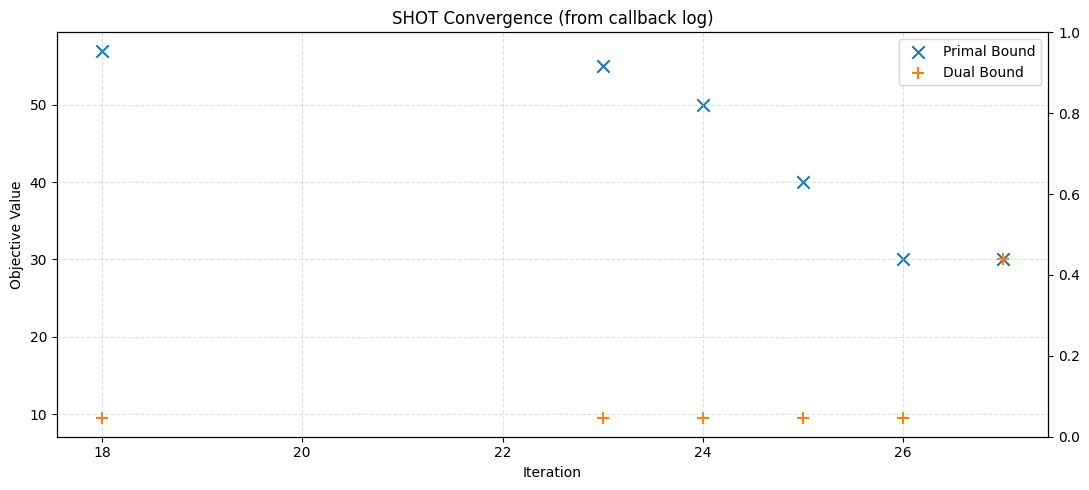

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Build DataFrame from callback log
# ------------------------------------------------------------
df_conv = pd.DataFrame(primal_log)

if df_conv.empty:
    print("No primal updates recorded.")

else:

    df_conv = df_conv.sort_values("iter")

    # ------------------------------------------------------------
    # Plot
    # ------------------------------------------------------------
    fig, ax1 = plt.subplots(figsize=(11, 5))
    ax2 = ax1.twinx()

    # incumbent points
    ax1.scatter(
        df_conv["iter"],
        df_conv["obj"],
        s=80,
        marker='x',
        label="Primal Bound"
    )

    # dual bound points
    ax1.scatter(
        df_conv["iter"],
        df_conv["dual"],
        s=80,
        marker='+',
        label="Dual Bound"
    )

    # labels
    ax1.set_xlabel("Iteration")
    ax1.set_ylabel("Objective Value")

    ax1.set_title("SHOT Convergence (from callback log)")

    ax1.grid(True, linestyle='--', alpha=0.4)

    # combined legend
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()

    ax1.legend(h1 + h2, l1 + l2, loc='best')

    plt.tight_layout()
    plt.show()

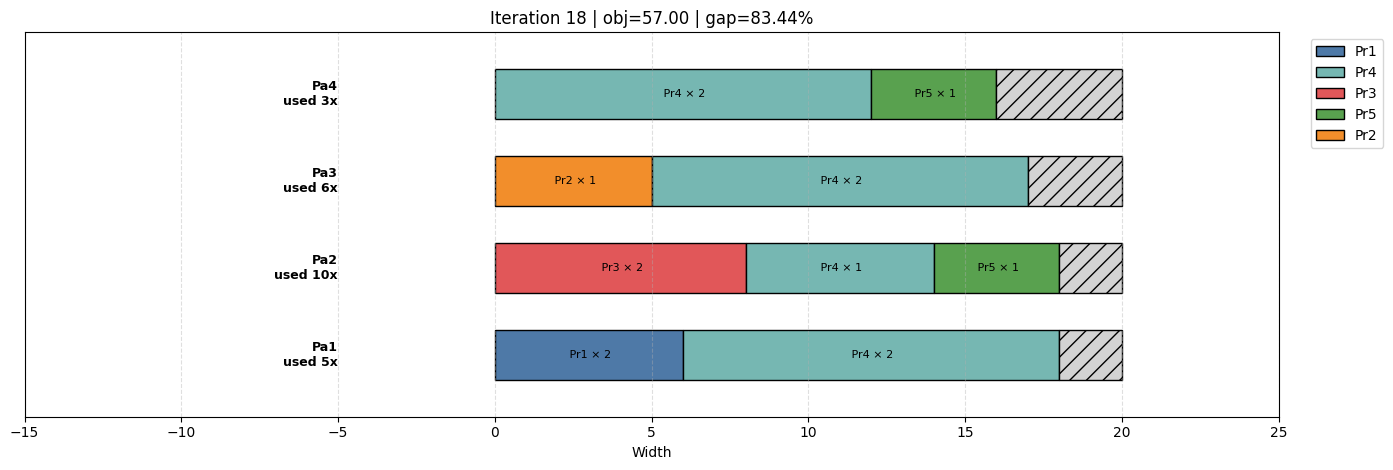

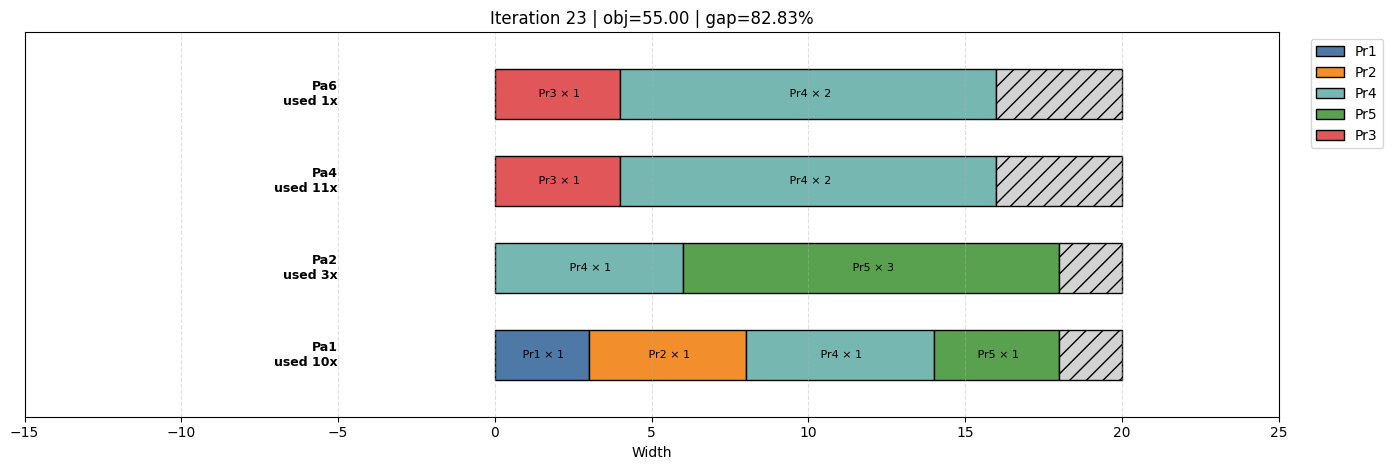

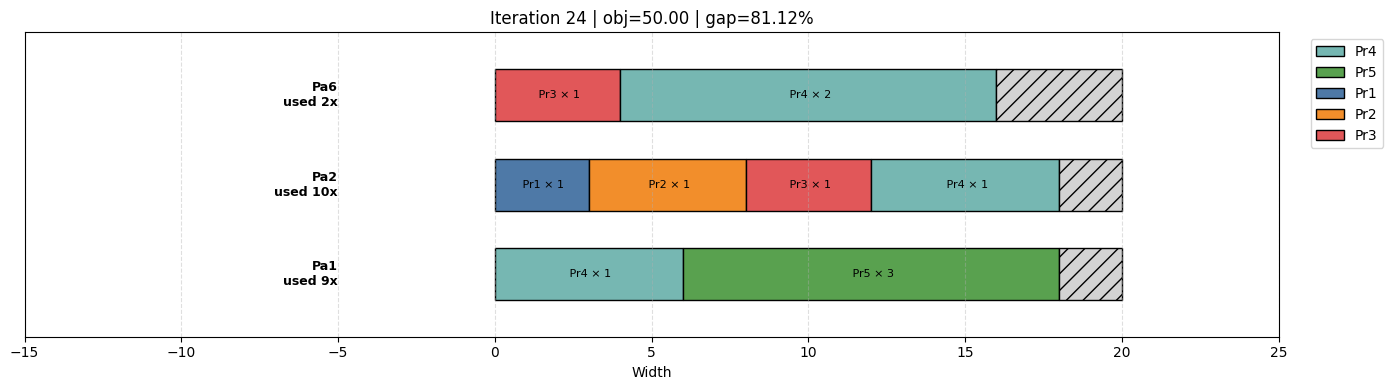

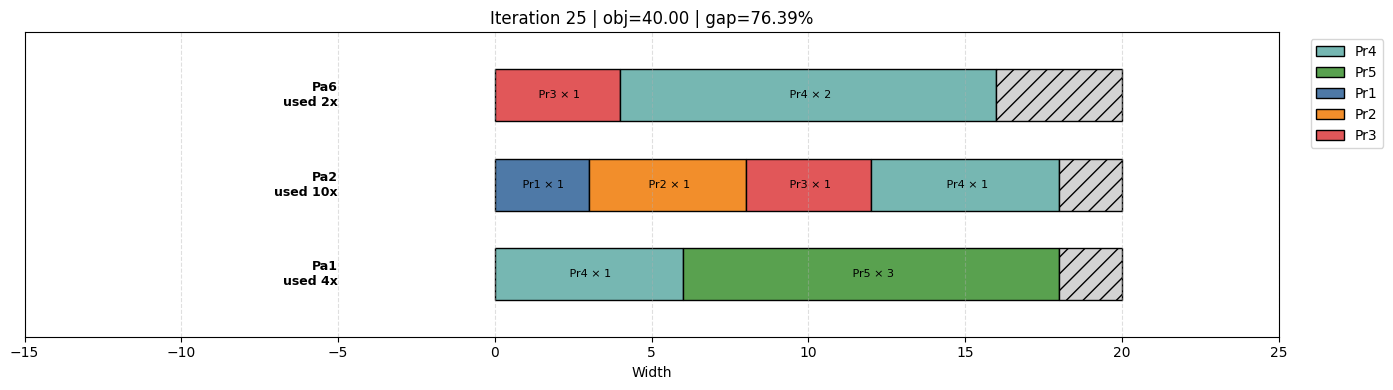

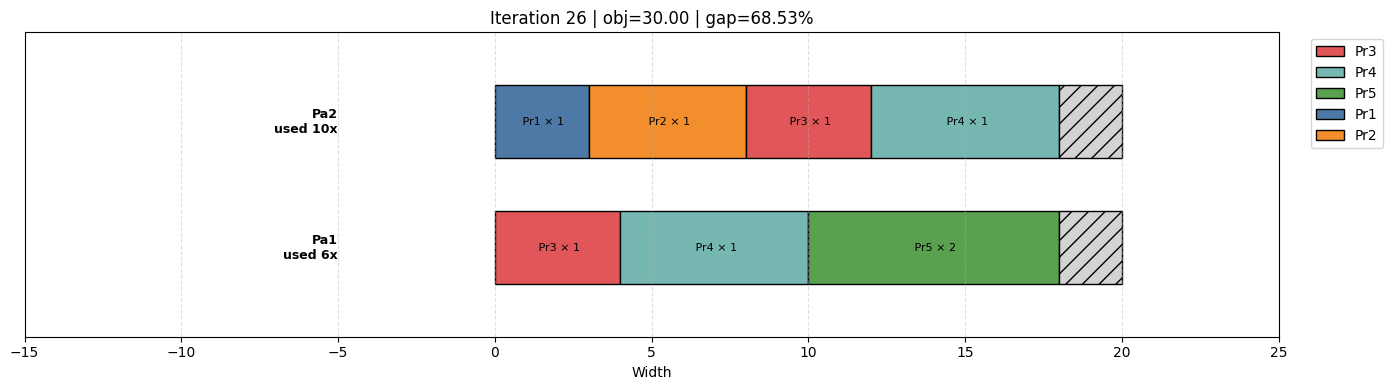

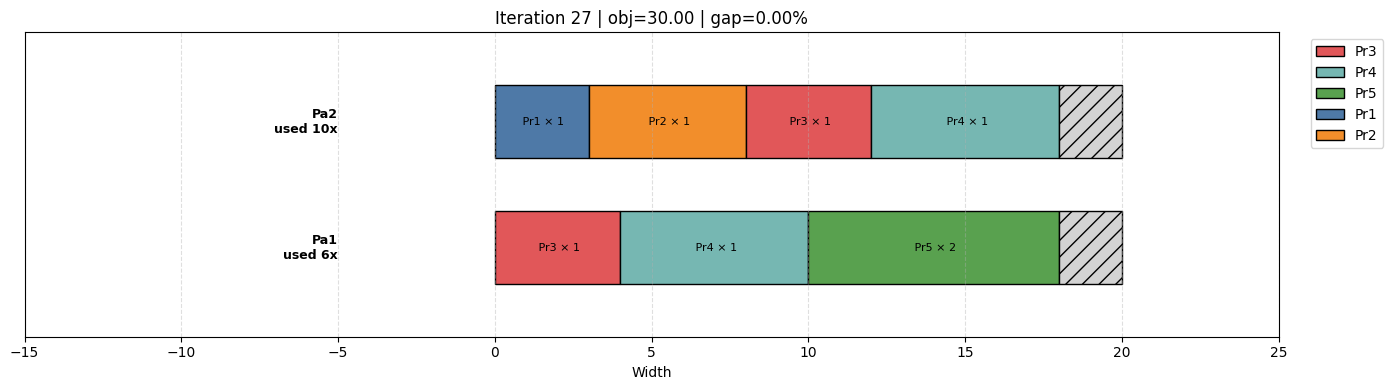

In [46]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

if not primal_log:
    print("No primal solutions recorded")

else:

    color_palette = [
        "#4E79A7", "#F28E2B", "#E15759", "#76B7B2",
        "#59A14F", "#EDC948", "#B07AA1", "#FF9DA7",
        "#9C755F", "#BAB0AC"
    ]

    product_colors = {
        products[i]: color_palette[i % len(color_palette)]
        for i in I
    }

    for step, row in enumerate(primal_log):

        sol = row["sol"]

        pattern_data = []

        for j in J:

            m_val = round(sol[m[j].index])
            if m_val <= 0:
                continue

            cuts = []
            used_width = 0.0

            for i in I:

                n_val = round(sol[n[i, j].index])

                if n_val > 0:
                    cuts.append({
                        "product": products[i],
                        "count": n_val,
                        "width": weights[i]
                    })
                    used_width += n_val * weights[i]

            trim = weights_max[j] - used_width

            pattern_data.append({
                "pattern": patterns[j],
                "repetitions": m_val,
                "roll_width": weights_max[j],
                "used_width": used_width,
                "trim": trim,
                "cuts": cuts
            })

        # ---------------- plot ----------------

        fig_height = max(4, len(pattern_data) * 1.2)
        fig, ax = plt.subplots(figsize=(14, fig_height))

        y_pos = 0
        bar_height = 0.7
        legend_handles = {}

        for pdata in pattern_data:

            x_start = 0

            for cut in pdata["cuts"]:

                product = cut["product"]
                count = cut["count"]
                width = cut["width"]

                total = count * width

                rect = patches.Rectangle(
                    (x_start, y_pos),
                    total,
                    bar_height,
                    facecolor=product_colors[product],
                    edgecolor='black'
                )

                ax.add_patch(rect)

                ax.text(
                    x_start + total / 2,
                    y_pos + bar_height / 2,
                    f" {product} × {count}",
                    ha='center',
                    va='center',
                    fontsize=8
                )

                if product not in legend_handles:
                    legend_handles[product] = patches.Patch(
                        facecolor=product_colors[product],
                        edgecolor='black',
                        label=product
                    )

                x_start += total

            trim = pdata["trim"]

            if trim > 1e-6:
                ax.add_patch(patches.Rectangle(
                    (x_start, y_pos),
                    trim,
                    bar_height,
                    facecolor='lightgray',
                    edgecolor='black',
                    hatch='//'
                ))

            ax.text(
                -5,
                y_pos + bar_height / 2,
                f"{pdata['pattern']}\nused {pdata['repetitions']}x",
                ha='right',
                va='center',
                fontsize=9,
                fontweight='bold'
            )

            y_pos += 1.2

        max_width = max(weights_max)

        ax.set_xlim(-15, max_width + 5)
        ax.set_ylim(-0.5, y_pos)

        ax.set_title(
            f"Iteration {row['iter']} | obj={row['obj']:.2f} | gap={row['gap (%)']:.2f}%"
        )

        ax.set_yticks([])
        ax.set_xlabel("Width")
        ax.grid(axis='x', linestyle='--', alpha=0.4)

        ax.legend(
            handles=list(legend_handles.values()),
            loc='upper left',
            bbox_to_anchor=(1.02, 1)
        )

        plt.tight_layout()
        plt.show()